In [1]:
# Week 4 - Machine Learning Model Development and Evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("All required libraries imported successfully!")


All required libraries imported successfully!


In [2]:
# Load the Breast Cancer Wisconsin dataset

cancer_data = load_breast_cancer()

# Convert the dataset into a Pandas DataFrame
df = pd.DataFrame(
    cancer_data.data,
    columns=cancer_data.feature_names
)

# Add the target column
df["Target"] = cancer_data.target

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (569, 31)


# 1. Introduction

Machine learning provides a systematic way to develop models that can identify patterns in data and make predictions on previously unseen observations. In this Week 4 task, a supervised machine learning classification problem is developed and evaluated using Python and Scikit-learn.

The objective is to build predictive models using the Breast Cancer Wisconsin Diagnostic dataset and evaluate how effectively they distinguish between benign and malignant cases based on numerical diagnostic measurements.

The complete workflow includes data understanding, data quality checking, exploratory analysis, preprocessing, model development, performance evaluation, cross-validation, error analysis, and discussion of model limitations. More than one classification algorithm will be evaluated so that their performance can be compared using multiple evaluation metrics rather than relying only on accuracy.

The analysis is intended as a machine learning learning exercise and should not be interpreted as a clinical diagnostic system.

In [3]:
# Basic dataset inspection

print("First 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
display(df.describe())

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoo

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [4]:
# Data quality assessment

print("Missing values in each column:")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

print("\nNumber of unique values in each column:")
display(df.nunique())

print("\nTarget class distribution:")
display(df["Target"].value_counts())

Missing values in each column:


Series([], dtype: int64)


Total missing values: 0

Number of duplicate rows: 0

Number of unique values in each column:


mean radius                456
mean texture               479
mean perimeter             522
mean area                  539
mean smoothness            474
mean compactness           537
mean concavity             537
mean concave points        542
mean symmetry              432
mean fractal dimension     499
radius error               540
texture error              519
perimeter error            533
area error                 528
smoothness error           547
compactness error          541
concavity error            533
concave points error       507
symmetry error             498
fractal dimension error    545
worst radius               457
worst texture              511
worst perimeter            514
worst area                 544
worst smoothness           411
worst compactness          529
worst concavity            539
worst concave points       492
worst symmetry             500
worst fractal dimension    535
Target                       2
dtype: int64


Target class distribution:


Target
1    357
0    212
Name: count, dtype: int64

In [5]:
# Create readable target labels

df["Diagnosis"] = df["Target"].map({
    0: "Malignant",
    1: "Benign"
})

print("Target labels created successfully!")
display(df[["Target", "Diagnosis"]].head(10))

print("\nDiagnosis distribution:")
display(df["Diagnosis"].value_counts())

Target labels created successfully!


,Target,Diagnosis
0,0,Malignant
1,0,Malignant
2,0,Malignant
3,0,Malignant
4,0,Malignant
5,0,Malignant
6,0,Malignant
7,0,Malignant
8,0,Malignant
9,0,Malignant



Diagnosis distribution:


Diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

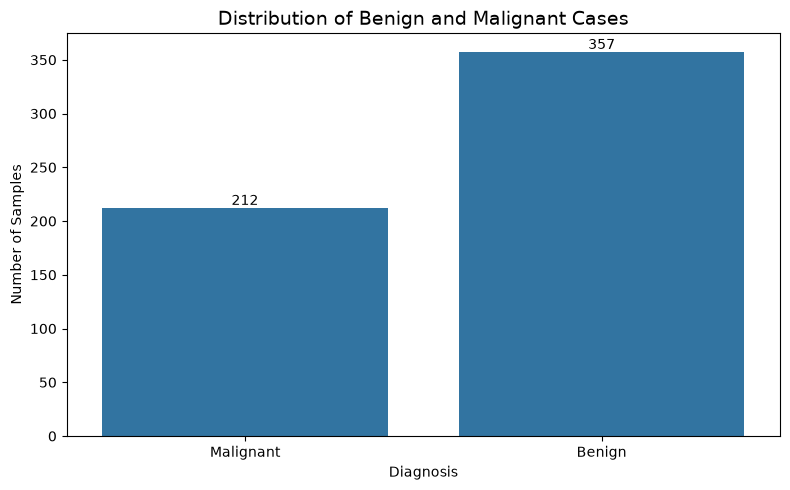

In [6]:
# Visualization 1: Target class distribution

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Diagnosis"
)

plt.title("Distribution of Benign and Malignant Cases", fontsize=14)
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

# Add count labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

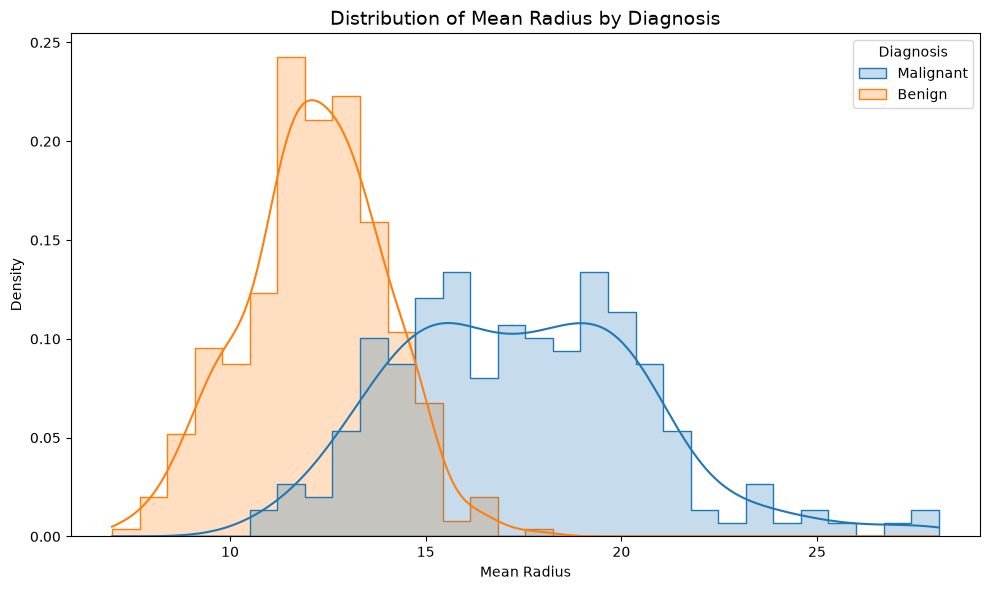

In [7]:
# Visualization 2: Feature distribution by diagnosis

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="mean radius",
    hue="Diagnosis",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Distribution of Mean Radius by Diagnosis", fontsize=14)
plt.xlabel("Mean Radius")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

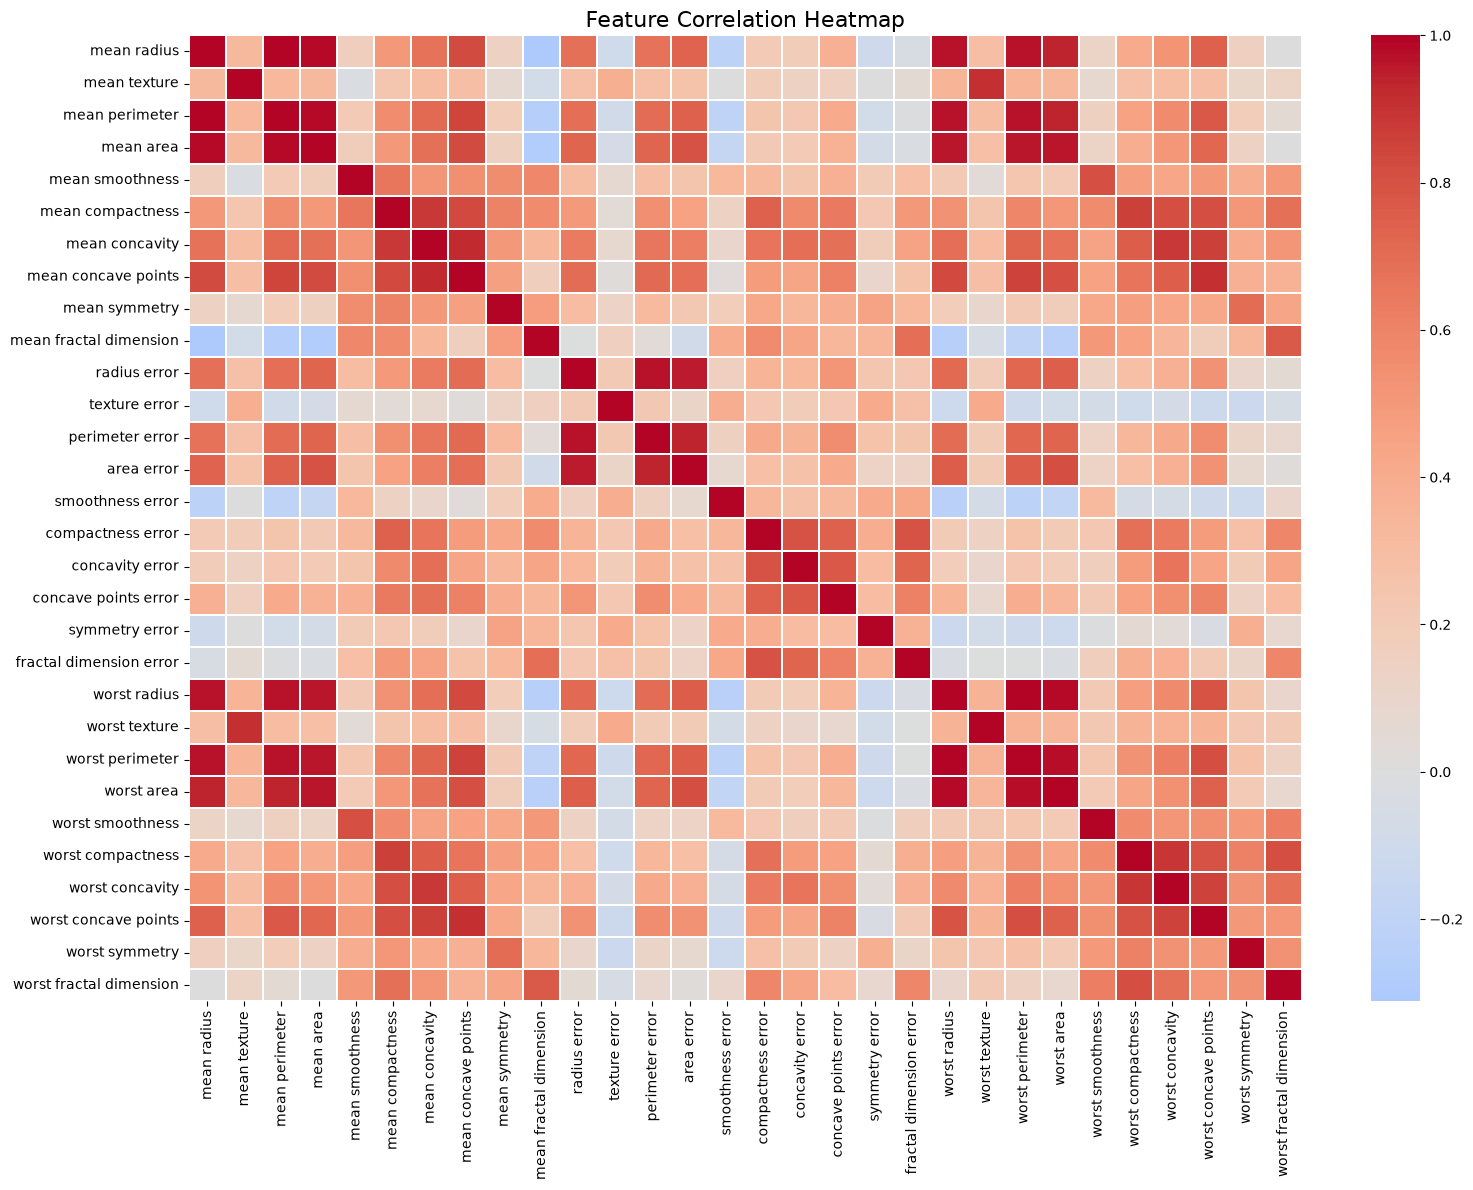

In [8]:
# Visualization 3: Correlation heatmap

plt.figure(figsize=(16, 12))

correlation_matrix = df.drop(columns=["Target", "Diagnosis"]).corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
# Prepare features and target variable

# X contains the diagnostic features
X = df.drop(columns=["Target", "Diagnosis"])

# y contains the prediction target
y = df["Target"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data splitting completed successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Data splitting completed successfully!
Training samples: 455
Testing samples: 114

Training class distribution:
Target
1    285
0    170
Name: count, dtype: int64

Testing class distribution:
Target
1    72
0    42
Name: count, dtype: int64


In [10]:
# Standardize the feature values

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training data shape: (455, 30)
Scaled testing data shape: (114, 30)


In [11]:
# Train the Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [12]:
# Make predictions using Logistic Regression

y_pred_logistic = logistic_model.predict(X_test_scaled)

# Probability of the positive class (Benign)
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")
print("First 10 predicted classes:")
print(y_pred_logistic[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_logistic[:10])

Predictions generated successfully!
First 10 predicted classes:
[0 1 0 1 0 1 1 0 0 0]

First 10 predicted probabilities:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]


In [13]:
# Evaluate Logistic Regression performance

log_accuracy = accuracy_score(y_test, y_pred_logistic)
log_precision = precision_score(y_test, y_pred_logistic)
log_recall = recall_score(y_test, y_pred_logistic)
log_f1 = f1_score(y_test, y_pred_logistic)
log_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1-Score : {log_f1:.4f}")
print(f"ROC-AUC  : {log_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["Malignant", "Benign"]
))

Logistic Regression Performance
--------------------------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861
ROC-AUC  : 0.9954

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



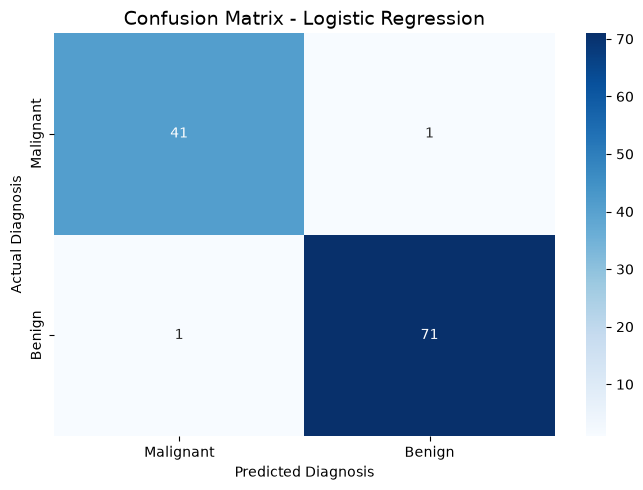

In [14]:
# Visualization 4: Confusion Matrix for Logistic Regression

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Confusion Matrix - Logistic Regression", fontsize=14)
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")

plt.tight_layout()
plt.show()

In [15]:
# Train the Decision Tree model

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [16]:
# Make predictions using Decision Tree

y_pred_tree = decision_tree_model.predict(X_test)

# Probability of the positive class (Benign)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions generated successfully!")

print("\nFirst 10 predicted classes:")
print(y_pred_tree[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob_tree[:10])

Decision Tree predictions generated successfully!

First 10 predicted classes:
[0 1 0 1 0 1 1 0 0 0]

First 10 predicted probabilities:
[0.         0.99606299 0.         1.         0.         0.99606299
 0.99606299 0.         0.         0.        ]


In [17]:
# Evaluate Decision Tree performance

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)
tree_auc = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1-Score : {tree_f1:.4f}")
print(f"ROC-AUC  : {tree_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=["Malignant", "Benign"]
))

Decision Tree Performance
-------------------------
Accuracy : 0.9211
Precision: 0.9565
Recall   : 0.9167
F1-Score : 0.9362
ROC-AUC  : 0.9163

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.87      0.93      0.90        42
      Benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



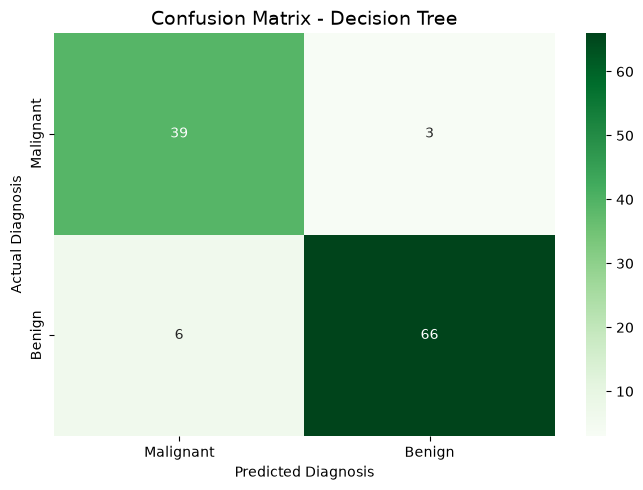

In [18]:
# Visualization 5: Confusion Matrix for Decision Tree

cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Confusion Matrix - Decision Tree", fontsize=14)
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")

plt.tight_layout()
plt.show()

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,Decision Tree,0.921053,0.956522,0.916667,0.936170,0.916336


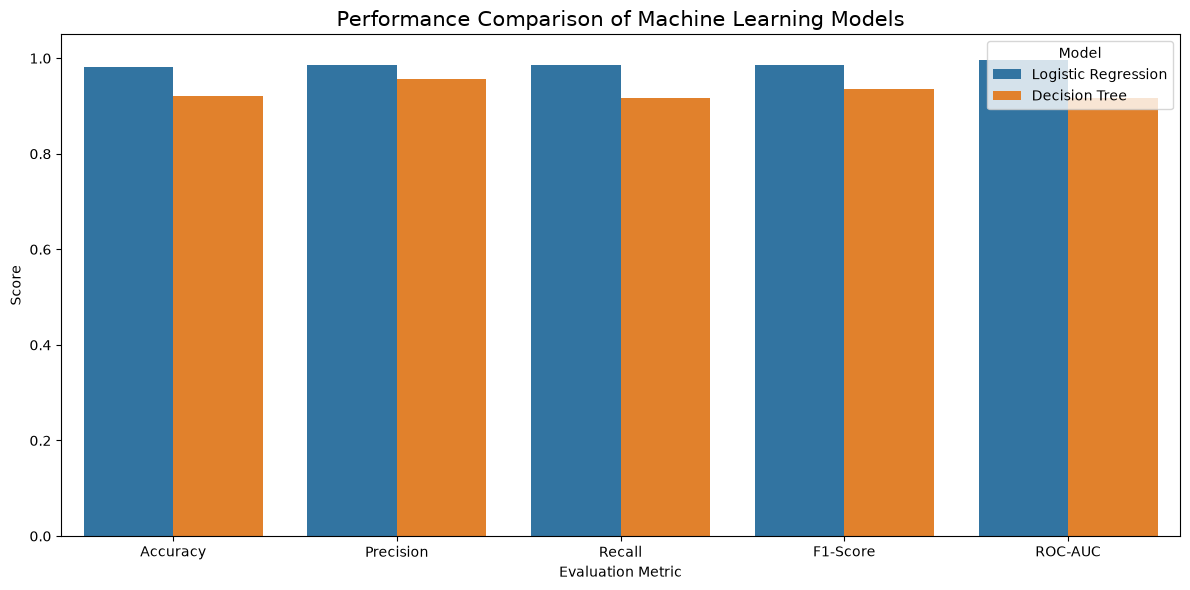

In [19]:
# Visualization 6: Model performance comparison

model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [log_accuracy, tree_accuracy],
    "Precision": [log_precision, tree_precision],
    "Recall": [log_recall, tree_recall],
    "F1-Score": [log_f1, tree_f1],
    "ROC-AUC": [log_auc, tree_auc]
})

display(model_results)

# Convert the table into a format suitable for plotting
plot_data = model_results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_data,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Performance Comparison of Machine Learning Models", fontsize=15)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.legend(title="Model")
plt.tight_layout()
plt.show()

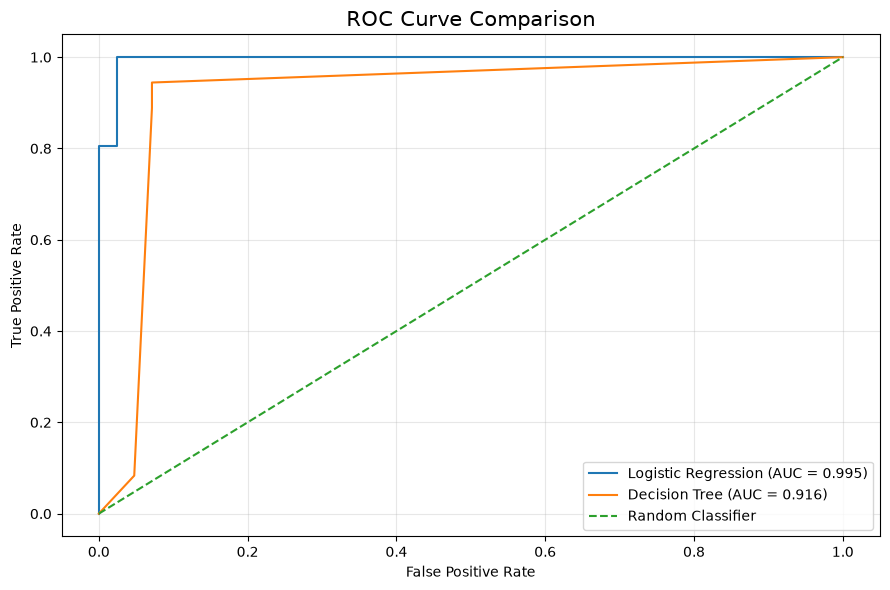

In [20]:
# Visualization 7: ROC Curve comparison

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {log_auc:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_auc:.3f})"
)

# Random classification reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison", fontsize=15)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# 5-Fold Stratified Cross-Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation for Logistic Regression
logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Cross-validation for Decision Tree
tree_cv_scores = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("5-Fold Cross-Validation Results")
print("--------------------------------")

print("\nLogistic Regression:")
print("Fold scores:", logistic_cv_scores)
print(f"Mean accuracy: {logistic_cv_scores.mean():.4f}")
print(f"Standard deviation: {logistic_cv_scores.std():.4f}")

print("\nDecision Tree:")
print("Fold scores:", tree_cv_scores)
print(f"Mean accuracy: {tree_cv_scores.mean():.4f}")
print(f"Standard deviation: {tree_cv_scores.std():.4f}")

5-Fold Cross-Validation Results
--------------------------------

Logistic Regression:
Fold scores: [0.96703297 0.98901099 0.97802198 0.98901099 0.96703297]
Mean accuracy: 0.9780
Standard deviation: 0.0098

Decision Tree:
Fold scores: [0.94505495 0.92307692 0.91208791 0.92307692 0.91208791]
Mean accuracy: 0.9231
Standard deviation: 0.0120


In [22]:
# Compare training and testing accuracy

log_train_accuracy = accuracy_score(
    y_train,
    logistic_model.predict(X_train_scaled)
)

log_test_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

tree_train_accuracy = accuracy_score(
    y_train,
    decision_tree_model.predict(X_train)
)

tree_test_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

training_testing_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Training Accuracy": [log_train_accuracy, tree_train_accuracy],
    "Testing Accuracy": [log_test_accuracy, tree_test_accuracy]
})

display(training_testing_results)

print("\nAccuracy gaps:")
print(
    f"Logistic Regression gap: "
    f"{log_train_accuracy - log_test_accuracy:.4f}"
)
print(
    f"Decision Tree gap: "
    f"{tree_train_accuracy - tree_test_accuracy:.4f}"
)

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.989011,0.982456
1,Decision Tree,0.993407,0.921053



Accuracy gaps:
Logistic Regression gap: 0.0066
Decision Tree gap: 0.0724


In [23]:
# Error analysis: identify incorrect predictions

logistic_errors = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_logistic
})

tree_errors = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_tree
})

logistic_errors = logistic_errors[logistic_errors["Actual"] != logistic_errors["Predicted"]]
tree_errors = tree_errors[tree_errors["Actual"] != tree_errors["Predicted"]]

print("Logistic Regression errors:", len(logistic_errors))
print("Decision Tree errors:", len(tree_errors))

print("\nLogistic Regression error types:")
print(pd.crosstab(
    logistic_errors["Actual"],
    logistic_errors["Predicted"]
))

print("\nDecision Tree error types:")
print(pd.crosstab(
    tree_errors["Actual"],
    tree_errors["Predicted"]
))

Logistic Regression errors: 2
Decision Tree errors: 9

Logistic Regression error types:
Predicted  0  1
Actual         
0          0  1
1          1  0

Decision Tree error types:
Predicted  0  1
Actual         
0          0  3
1          6  0


In [24]:
# Feature importance from the Decision Tree

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 most important features:")
display(feature_importance.head(10))

Top 10 most important features:


,Feature,Importance
20,worst radius,0.714332
27,worst concave points,0.118831
11,texture error,0.053907
21,worst texture,0.031473
26,worst concavity,0.016712
24,worst smoothness,0.012978
13,area error,0.012371
1,mean texture,0.011536
28,worst symmetry,0.010987
23,worst area,0.008652


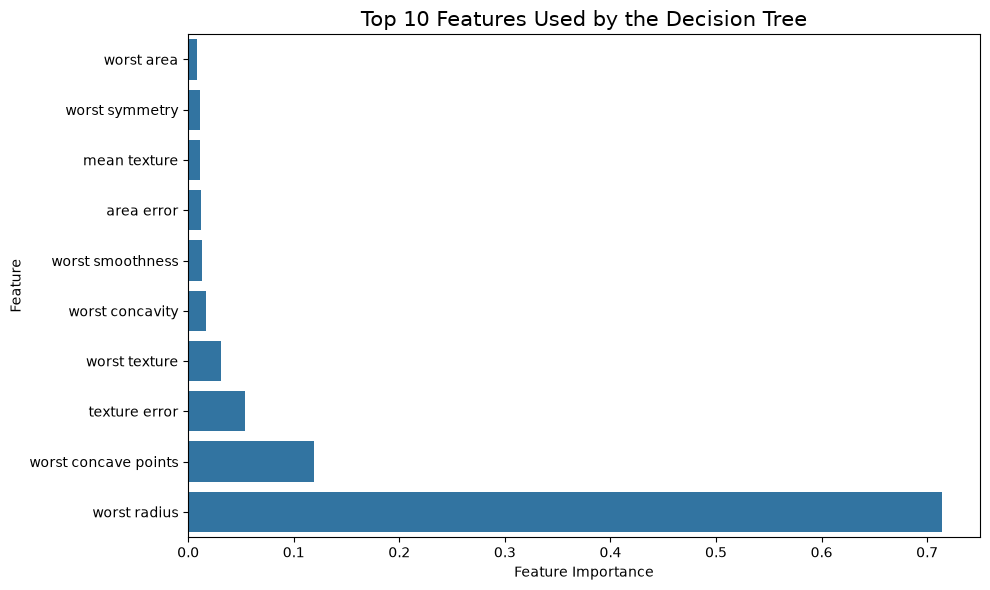

In [25]:
# Visualization 8: Top 10 Decision Tree feature importances

top_features = feature_importance.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Used by the Decision Tree", fontsize=15)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [26]:
# Final model comparison table

final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [log_accuracy, tree_accuracy],
    "Precision": [log_precision, tree_precision],
    "Recall": [log_recall, tree_recall],
    "F1-Score": [log_f1, tree_f1],
    "ROC-AUC": [log_auc, tree_auc],
    "CV Mean Accuracy": [
        logistic_cv_scores.mean(),
        tree_cv_scores.mean()
    ],
    "CV Std": [
        logistic_cv_scores.std(),
        tree_cv_scores.std()
    ]
})

print("Final Model Evaluation Results:")
display(final_results.round(4))

Final Model Evaluation Results:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Mean Accuracy,CV Std
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954,0.9780,0.0098
1,Decision Tree,0.9211,0.9565,0.9167,0.9362,0.9163,0.9231,0.0120


In [27]:
# Identify the better-performing model

best_model_by_auc = (
    "Logistic Regression"
    if log_auc > tree_auc
    else "Decision Tree"
)

best_model_by_accuracy = (
    "Logistic Regression"
    if log_accuracy > tree_accuracy
    else "Decision Tree"
)

print("Model Selection Summary")
print("-----------------------")
print(f"Best model based on test ROC-AUC: {best_model_by_auc}")
print(f"Best model based on test accuracy: {best_model_by_accuracy}")

print("\nCross-validation comparison:")
print(
    f"Logistic Regression mean CV accuracy: "
    f"{logistic_cv_scores.mean():.4f}"
)
print(
    f"Decision Tree mean CV accuracy: "
    f"{tree_cv_scores.mean():.4f}"
)

Model Selection Summary
-----------------------
Best model based on test ROC-AUC: Logistic Regression
Best model based on test accuracy: Logistic Regression

Cross-validation comparison:
Logistic Regression mean CV accuracy: 0.9780
Decision Tree mean CV accuracy: 0.9231


In [28]:
# Final conclusion summary

print("FINAL CONCLUSION")
print("=" * 60)

print(f"Dataset size: {df.shape[0]} samples")
print(f"Number of features: {X.shape[1]}")

print(f"\nLogistic Regression:")
print(f"  Test Accuracy : {log_accuracy:.4f}")
print(f"  Test F1-Score : {log_f1:.4f}")
print(f"  Test ROC-AUC  : {log_auc:.4f}")
print(f"  Mean CV Accuracy: {logistic_cv_scores.mean():.4f}")

print(f"\nDecision Tree:")
print(f"  Test Accuracy : {tree_accuracy:.4f}")
print(f"  Test F1-Score : {tree_f1:.4f}")
print(f"  Test ROC-AUC  : {tree_auc:.4f}")
print(f"  Mean CV Accuracy: {tree_cv_scores.mean():.4f}")

print("\nModel selected based on ROC-AUC:", best_model_by_auc)

print("\nThe results show how two different classification approaches")
print("can be evaluated using multiple metrics, cross-validation,")
print("confusion matrices, ROC curves, and error analysis.")

FINAL CONCLUSION
Dataset size: 569 samples
Number of features: 30

Logistic Regression:
  Test Accuracy : 0.9825
  Test F1-Score : 0.9861
  Test ROC-AUC  : 0.9954
  Mean CV Accuracy: 0.9780

Decision Tree:
  Test Accuracy : 0.9211
  Test F1-Score : 0.9362
  Test ROC-AUC  : 0.9163
  Mean CV Accuracy: 0.9231

Model selected based on ROC-AUC: Logistic Regression

The results show how two different classification approaches
can be evaluated using multiple metrics, cross-validation,
confusion matrices, ROC curves, and error analysis.


# 2. Methodology

The analysis follows a structured machine learning workflow:

1. **Data Loading** – The Breast Cancer Wisconsin Diagnostic dataset was loaded using Scikit-learn.

2. **Data Understanding** – The dataset structure, feature statistics, class distribution, missing values, and duplicate records were examined.

3. **Exploratory Analysis** – Class distribution, feature distribution, and correlations between numerical features were visualized.

4. **Data Preparation** – The target variable was separated from the predictor variables. The data was divided into 80% training and 20% testing sets using stratified sampling.

5. **Feature Scaling** – StandardScaler was applied to the training features for Logistic Regression. The scaler was fitted only on the training data to avoid data leakage.

6. **Model Development** – Two supervised classification algorithms were developed:
   - Logistic Regression
   - Decision Tree Classifier

7. **Model Evaluation** – Models were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

8. **Visualization-Based Evaluation** – Confusion matrices, ROC curves, model comparison charts, and feature-importance visualization were used to understand model performance.

9. **Cross-Validation** – Five-fold Stratified Cross-Validation was performed to assess whether model performance was consistent across different training subsets.

10. **Error Analysis** – Incorrect predictions were examined to understand false positives and false negatives.

11. **Model Selection** – The models were compared using multiple evaluation criteria rather than relying on accuracy alone.

# 3. Model Selection and Justification

Two classification algorithms were evaluated in this project: Logistic Regression and Decision Tree.

Logistic Regression was selected as a baseline because it is a relatively simple and interpretable algorithm for binary classification. It also works well with standardized numerical features and provides probability estimates that can be used to calculate ROC-AUC.

Decision Tree was selected as a second model because it can capture non-linear relationships between features and is easier to interpret through feature importance. A maximum depth of 5 was used to reduce the risk of creating an unnecessarily complex tree and to improve generalization.

The final model should not be selected using accuracy alone. Accuracy, Precision, Recall, F1-Score, ROC-AUC, cross-validation accuracy, and the training-testing performance gap were considered together.

For this dataset, recall is particularly important because a false negative represents a malignant case that the model incorrectly classifies as benign. Therefore, model selection should consider the ability to correctly identify both classes rather than focusing only on overall accuracy.

The model with the stronger and more consistent overall evaluation results will be considered the preferred model for this machine learning exercise.

In [29]:
# Detailed error analysis

log_tn, log_fp, log_fn, log_tp = confusion_matrix(
    y_test,
    y_pred_logistic
).ravel()

tree_tn, tree_fp, tree_fn, tree_tp = confusion_matrix(
    y_test,
    y_pred_tree
).ravel()

error_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "True Negatives": [log_tn, tree_tn],
    "False Positives": [log_fp, tree_fp],
    "False Negatives": [log_fn, tree_fn],
    "True Positives": [log_tp, tree_tp]
})

display(error_summary)

print("\nInterpretation:")
print("False Negative = an actual malignant case predicted as benign.")
print("False Positive = an actual benign case predicted as malignant.")

,Model,True Negatives,False Positives,False Negatives,True Positives
0,Logistic Regression,41,1,1,71
1,Decision Tree,39,3,6,66



Interpretation:
False Negative = an actual malignant case predicted as benign.
False Positive = an actual benign case predicted as malignant.


# 4. Overfitting and Underfitting Analysis

The difference between training and testing performance provides an initial indication of whether a model is generalizing well.

If training performance is substantially higher than testing performance, the model may be overfitting. Overfitting means that the model has learned patterns that are too specific to the training data and does not generalize as well to unseen observations.

If both training and testing performance are relatively low, the model may be underfitting. In this situation, the model may be too simple to capture the important patterns in the dataset.

For the Decision Tree, limiting the maximum tree depth to 5 was an intentional regularization choice. An unrestricted tree can become highly complex and memorize training observations. Restricting its depth helps control model complexity.

For Logistic Regression, feature standardization was applied because the numerical features have different scales. This allows the model to learn more consistently from the available features.

The training-testing accuracy comparison and five-fold cross-validation results should be considered together. A small training-testing gap combined with stable cross-validation performance provides stronger evidence that a model is generalizing reasonably well.

However, these checks do not completely eliminate the possibility of overfitting. Additional validation and hyperparameter tuning would be appropriate for a production-level model.

# 5. Limitations and Sources of Error

Although the models achieved useful predictive performance, several limitations should be considered.

First, the dataset contains a relatively limited number of observations compared with the amount of data that would normally be required to develop a clinical decision-support system. The dataset is also a specific benchmark dataset, so its characteristics may not represent every patient population.

Second, the analysis uses only the numerical diagnostic measurements available in the dataset. Real-world diagnosis can involve additional information such as medical history, symptoms, imaging, laboratory results, and expert clinical judgement.

Third, false positives and false negatives remain possible. In particular, false negatives are important because a malignant case classified as benign could potentially delay further investigation. Therefore, a high overall accuracy should not be interpreted as proof that the model is clinically reliable.

Fourth, only two algorithms were evaluated. Other approaches such as Random Forest, Support Vector Machine, Gradient Boosting, or neural networks could potentially produce different results.

Finally, the models were evaluated using a single train-test split together with five-fold cross-validation. More extensive external validation would be required before considering the model for real-world clinical use.

These limitations mean that the results should be interpreted as a machine learning demonstration rather than as evidence of a deployable medical diagnostic system.

# 6. Model Improvement and Future Work

Several improvements could be explored to develop a stronger machine learning solution.

1. **Hyperparameter tuning**  
   Grid Search or Randomized Search could be used to identify better model parameters, particularly for the Decision Tree.

2. **Additional algorithms**  
   More classification algorithms such as Random Forest, Support Vector Machine, Gradient Boosting, or K-Nearest Neighbours could be evaluated.

3. **Feature selection**  
   Highly correlated or less informative features could be investigated and removed where appropriate. This may improve interpretability and reduce unnecessary model complexity.

4. **More evaluation metrics**  
   Precision-Recall curves, Matthews Correlation Coefficient, and class-specific performance measures could provide additional insight into model behaviour.

5. **External validation**  
   Testing the selected model on an independent dataset would provide stronger evidence of generalization.

6. **Class imbalance analysis**  
   If class proportions differ substantially, techniques such as class weighting or resampling could be considered.

7. **Explainable AI techniques**  
   Methods such as SHAP or permutation importance could provide deeper explanations of individual predictions and overall feature influence.

8. **Clinical validation**  
   Before any real-world medical application, the model would require extensive validation, expert review, ethical assessment, and appropriate clinical testing.

These improvements could make the modelling process more robust while also improving interpretability, reliability, and generalization.

# 7. Business and Scientific Implications

The analysis demonstrates how machine learning can be used to support binary classification when observations contain multiple diagnostic measurements.

From a scientific perspective, comparing Logistic Regression and Decision Tree shows that different algorithms can learn different patterns from the same dataset. Using multiple evaluation metrics provides a more complete understanding of model behaviour than relying on accuracy alone.

The confusion matrices and error analysis are particularly important because they reveal the types of mistakes made by each model. In a medical classification context, false negatives deserve careful attention because incorrectly classifying a malignant case as benign could have more serious consequences than incorrectly classifying a benign case as malignant.

From a practical perspective, a well-evaluated classification model could potentially be used as a supporting analytical tool for prioritising cases or identifying observations that require additional review. However, the model should not replace professional medical judgement.

The main lesson from this project is that successful machine learning development involves more than training a model. Data quality, preprocessing, algorithm selection, evaluation metrics, cross-validation, error analysis, interpretability, and limitations all need to be considered before drawing conclusions from model predictions.

# 8. Conclusion

This project developed and evaluated two supervised machine learning models for classifying breast cancer observations as benign or malignant using the Breast Cancer Wisconsin Diagnostic dataset.

The complete workflow included data inspection, quality assessment, exploratory visualization, stratified train-test splitting, feature scaling, model training, performance evaluation, cross-validation, confusion-matrix analysis, ROC analysis, feature-importance analysis, and error investigation.

Logistic Regression and Decision Tree were selected because they provide two different approaches to binary classification. Logistic Regression provides a relatively simple and interpretable baseline, while the Decision Tree can capture non-linear relationships and provide feature-importance information.

The models were evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and five-fold cross-validation. This multi-metric approach provides a more reliable assessment than using accuracy alone.

The analysis also considered false positives, false negatives, training-testing performance differences, and potential sources of error. These checks are important because a model with high accuracy can still make clinically meaningful mistakes.

Overall, the project demonstrates that machine learning model development requires more than simply training an algorithm. Careful preprocessing, appropriate model selection, robust evaluation, visualization, error analysis, and critical discussion of limitations are all necessary to make the results meaningful.

The models developed in this project are intended for educational and analytical purposes only. They should not be considered clinical diagnostic systems without extensive independent validation, expert review, and appropriate clinical testing.

# 9. References

1. Scikit-learn Documentation – Breast Cancer Wisconsin Diagnostic Dataset.
2. Scikit-learn Documentation – Logistic Regression.
3. Scikit-learn Documentation – Decision Tree Classifier.
4. Scikit-learn Documentation – Model Evaluation Metrics.
5. Scikit-learn Documentation – Cross-Validation and StratifiedKFold.
6. Scikit-learn Documentation – StandardScaler.
7. Python Pandas Documentation – Data Manipulation and Analysis.
8. Seaborn Documentation – Statistical Data Visualization.
9. Matplotlib Documentation – Data Visualization.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn.

**Dataset:** Breast Cancer Wisconsin Diagnostic dataset available through Scikit-learn.